## step 1 Data colection 

In [76]:
import pandas
import yfinance as yf

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
df.head()
    

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.237549,24.705318,23.798599,24.694233,212818400
2015-01-05,23.554739,24.086799,23.368519,24.006990,257142000
2015-01-06,23.556959,23.816338,23.195601,23.619033,263188400
2015-01-07,23.887270,23.987031,23.654493,23.765339,160423600
2015-01-08,24.805079,24.862719,24.097882,24.215380,237458000


In [11]:
df1=df["Close"]

In [12]:
df1.shape

(2264, 1)

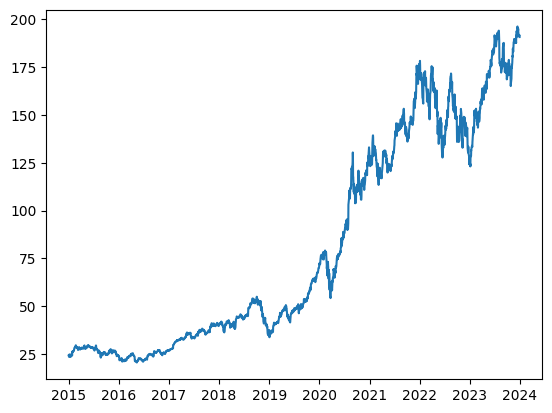

In [13]:
import matplotlib.pyplot as plt 
plt.plot(df1)

In [ ]:
# LSTM are sensitive to the scale of the data. so we apply MinMax Scaler

In [14]:
import numpy as np 

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

##### we have collected the data now we need to preprocess

## Step2: preprocess the data- Train and Test ---

In [15]:
# spliting the dataset into train and test split 
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [17]:
training_size, test_size 


(1471, 793)

In [18]:
len(train_data), len(test_data)

(1471, 793)

In [19]:
import numpy 
#convert an array of values into a dataset matrix 
def create_dataset(dataset, time_step=1):
    dataX,dataY=[],[]
    for i in range(len(dataset)-time_step-1):
        a=dataset[i:(i+time_step),0] ### i=0, 0,1,2,3,4
        dataX.append(a)
        dataY.append(dataset[i+time_step,0])
    return numpy.array(dataX), numpy.array(dataY)

In [20]:
# reshape into X=t,t+1,t+3,t+3 and Y=t+4
time_step=100
X_train, y_train=create_dataset(train_data,time_step)
X_test, y_test=create_dataset(test_data,time_step)

In [21]:
print(X_train.shape), print(y_train.shape) 

(1370, 100)
(1370,)


(None, None)

In [22]:
print(X_test.shape), print(y_test.shape)

(692, 100)
(692,)


(None, None)

## Step 3: LSTM model  

In [23]:
# Before the creation of model we need to reshape the input to be [samples , time setps, features ]
#which is required for LSTM 
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)


In [24]:
#create the stacked LSTM model 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM


In [25]:
model=Sequential()
model.add(LSTM(50,return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

D:\Data-Science-Projects\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.fit(X_train, y_train, validation_data=(X_test,y_test),epochs=100, batch_size=64, verbose=1)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step - loss: 0.0077 - val_loss: 0.0172
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - loss: 6.2316e-04 - val_loss: 0.0121
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 4.8468e-04 - val_loss: 0.0019
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - loss: 3.2855e-04 - val_loss: 0.0019
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 2.9097e-04 - val_loss: 0.0026
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - loss: 3.1478e-04 - val_loss: 0.0017
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 2.9767e-04 - val_loss: 0.0039
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 2.8438e-04 - val_loss: 0.0037
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - loss: 2.8507e-04 - val_loss: 0.0025
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - loss: 3.4551e-04 - val_loss: 0.0014
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - loss: 2.5812e-04 - val_loss: 0.0013
E

In [28]:
import tensorflow as tf 

In [29]:
tf.__version__

'2.20.0'

In [30]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [31]:
## transformback to original form 
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [32]:
## claculate the RMSE performance metrics
import math 
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train, train_predict))

49.06631010690761

In [33]:
#test the data RMSE
math.sqrt(mean_squared_error(y_test, test_predict))

154.30854640260338

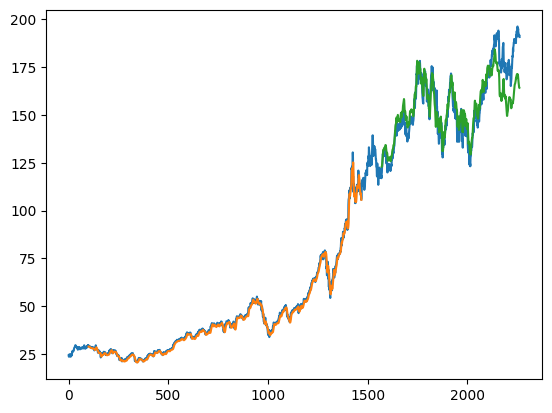

In [41]:
## ploting 
#shift train predictions from ploting
look_back=100
trainPredictPlot=numpy.empty_like(df1)
trainPredictPlot[:,:]=np.nan
trainPredictPlot[look_back:len(train_predict)+look_back,:]=train_predict
#shift test prediction for plotting 
testPredictPlot=numpy.empty_like(df1)
testPredictPlot[:,:]=numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1,:]=test_predict
#plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [42]:
len(test_data)

793

In [45]:
x_input=test_data[693:].reshape(1,-1)
x_input.shape

(1, 100)

In [46]:
# convert that into list 
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

## 

In [75]:
#demeostrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input{}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input=x_input.reshape((1,n_steps,1))
        #print(X_input)
        yhat=model.predict(x_input,verbose=0)
        print("{} day Output{}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input=x_input.reshape((1,n_steps,1))
        yhat=model.predict(x_input,verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        lst_output.extend(yhat.tolist())
        i=i+1
        
print(lst_output)
        

0 day input[0.88284091 0.87765908 0.89219073 0.90677867 0.91280514 0.91010151
 0.93395787 0.92493434 0.93982345 0.94303796 0.9526258  0.95251287
 0.96243889 0.9578707  0.96164934 0.95409198 0.95307674 0.95651711
 0.95070808 0.95397922 0.9612546  0.95104643 0.97354946 0.9673457
 0.97834334 0.98646456 0.97219578 0.98082476 0.99915415 1.
 0.99695454 0.98747972 0.99340142 0.98150155 0.98065553 0.97456444
 0.97146269 0.97202656 0.97445177 0.96852999 0.81821615 0.75497097
 0.6865052  0.6296919  0.58763331 0.55957061 0.54273522 0.53430921
 0.5312987  0.53132969 0.53256154 0.53343469 0.53369296 0.53242683
 0.52963889 0.52538204 0.52009964 0.51458693 0.50942403 0.50531358
 0.50307608 0.50286442 0.50448954 0.50781298 0.51268387 0.51868403
 0.52523559 0.53185439 0.53771979 0.54212201 0.54465115 0.54483593
 0.54243749 0.53762674 0.5312652  0.52372837 0.51545769 0.50691551
 0.49833569 0.49018267 0.48245981 0.47524285 0.46846929 0.462154
 0.45635369 0.45095849 0.44599372 0.44161195 0.43782401 0.4347

In [80]:
import matplotlib.pyplot as plt

In [81]:
len(df1)

2264

In [82]:
df3=df1.tolist()
df3.extend(lst_output)

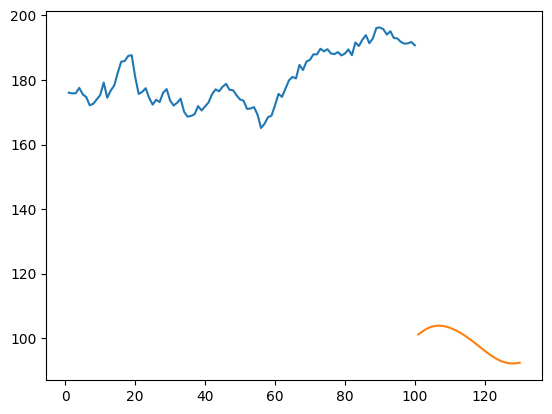

In [83]:
plt.plot(day_new,scaler.inverse_transform(df1[2164:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

In [77]:
len(lst_output)

30

In [73]:
day_pred.shape

(30,)